In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.varmax import VARMAX

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings("ignore")

**SARIMAX**

In [2]:
df = pd.read_csv("C:/Users/kerem/Desktop/EnerjiSon/claude/birlesik_veri.csv")
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime").set_index("Datetime")
df = df.astype(np.float32)

In [3]:
df_daily = df.resample("D").agg({
    "uretim_mwh"          : "sum",
    "tuketim_mwh"         : "sum",
    "fiyat_tl"            : "mean",
    "sicaklik"            : "mean",
    "hissedilen_sicaklik" : "mean",
    "nem"                 : "mean",
    "bulut_ortus"         : "mean",
    "ruzgar_hizi"         : "mean",
    "yagis"               : "sum",
    "is_weekend"          : "max",
    "is_holiday"          : "max",
}).dropna()

Feature Engineering

In [4]:
def add_fourier_features_calendar(df_daily: pd.DataFrame) -> pd.DataFrame:

    df_daily = df_daily.copy()
    ref_date = pd.Timestamp("2021-01-01")
    t = (df_daily.index - ref_date).days.values.astype(float)

    # Haftalık (T=7 gün)
    df_daily["sin_7"]     = np.sin(2 * np.pi * t / 7)
    df_daily["cos_7"]     = np.cos(2 * np.pi * t / 7)

    # Yıllık — 1. harmonik
    df_daily["sin_365"]   = np.sin(2 * np.pi * t / 365.25)
    df_daily["cos_365"]   = np.cos(2 * np.pi * t / 365.25)

    # Yıllık — 2. harmonik (yarı-yıllık mevsimsellik)
    df_daily["sin_365_2"] = np.sin(4 * np.pi * t / 365.25)
    df_daily["cos_365_2"] = np.cos(4 * np.pi * t / 365.25)

    return df_daily

# Lag özellikler — shift ile sızıntı yok
df_daily["uretim_lag_7"] = df_daily["uretim_mwh"].shift(7)
df_daily["load_lag_7"]   = df_daily["tuketim_mwh"].shift(7)
df_daily["price_lag_7"]  = df_daily["fiyat_tl"].shift(7)

# Hava lag1 — dünün verisi, gelecekte bilinebilir
df_daily["sicaklik_lag1"]   = df_daily["sicaklik"].shift(1)
df_daily["hissedilen_lag1"] = df_daily["hissedilen_sicaklik"].shift(1)
df_daily["nem_lag1"]        = df_daily["nem"].shift(1)
df_daily["ruzgar_lag1"]     = df_daily["ruzgar_hizi"].shift(1)
df_daily["bulut_lag1"]      = df_daily["bulut_ortus"].shift(1)
df_daily["yagis_lag1"]      = df_daily["yagis"].shift(1)

df_daily["sicaklik_sq"]  = df_daily["sicaklik_lag1"] ** 2
df_daily["sicaklik_abs"] = (df_daily["sicaklik_lag1"] - 18).abs()

df_daily = df_daily.dropna()

Target ve Exogenous Ayırma

In [5]:
df_daily = add_fourier_features_calendar(df_daily)

exog_load = df_daily[[
    "hissedilen_lag1",   # dünün hissedilen sıcaklığı
    "sicaklik_lag1",
    "sicaklik_sq",       # lag1'den türetilmeli — aşağıda düzeltildi
    "sicaklik_abs",      # lag1'den türetilmeli — aşağıda düzeltildi
    "nem_lag1",
    "ruzgar_lag1",
    "yagis_lag1",
    "is_weekend",
    "is_holiday",
    "load_lag_7",
    "sin_7",  "cos_7",
    "sin_365", "cos_365",
    "sin_365_2", "cos_365_2",
]]

exog_price = df_daily[[
    "hissedilen_lag1",
    "nem_lag1",
    "ruzgar_lag1",
    "bulut_lag1",
    "yagis_lag1",
    "is_weekend",
    "is_holiday",
    "load_lag_7",
    "price_lag_7",
    "uretim_lag_7",
    "sin_7", "cos_7",
    "sin_365", "cos_365",
]]

Train-Test Split

In [6]:
train_mask = df_daily.index.year <= 2023
val_mask   = df_daily.index.year == 2024
test_mask  = df_daily.index.year >= 2025

y_train_l = df_daily.loc[train_mask, "tuketim_mwh"]
y_val_l   = df_daily.loc[val_mask,   "tuketim_mwh"]
y_test_l  = df_daily.loc[test_mask,  "tuketim_mwh"]

y_train_p = df_daily.loc[train_mask, "fiyat_tl"]
y_val_p   = df_daily.loc[val_mask,   "fiyat_tl"]
y_test_p  = df_daily.loc[test_mask,  "fiyat_tl"]

X_train_load  = exog_load[train_mask]
X_val_load    = exog_load[val_mask]
X_test_load   = exog_load[test_mask]

X_train_price = exog_price[train_mask]
X_val_price   = exog_price[val_mask]
X_test_price  = exog_price[test_mask]

print(f"Eğitim : {y_train_l.index[0].date()} → {y_train_l.index[-1].date()}  ({len(y_train_l)} gün)")
print(f"Val    : {y_val_l.index[0].date()} → {y_val_l.index[-1].date()}  ({len(y_val_l)} gün)")
print(f"Test   : {y_test_l.index[0].date()} → {y_test_l.index[-1].date()}  ({len(y_test_l)} gün)")

Eğitim : 2021-01-08 → 2023-12-31  (1088 gün)
Val    : 2024-01-01 → 2024-12-31  (366 gün)
Test   : 2025-01-01 → 2025-12-31  (365 gün)


In [7]:
def stationarity_report(series: pd.Series, name: str,
                            max_lags: int = 14) -> dict:
    """
    ✅ Düzeltilmiş durağanlık raporu.

    Yenilikler:
    - ADF ✓ / KPSS ✗ çelişkisi artık "trend-durağan" olarak yorumlanıyor.
    - d önerisi bu durumda 0 (trend parametresiyle modellenir).
    - Ortak uyum (ADF ✗ / KPSS ✗) → d=1 önerir.
    """
    series = series.dropna()

    print(f"\n{'='*60}")
    print(f" Durağanlık Analizi — {name}")
    print(f"{'='*60}")

    # ADF Testi
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        adf_stat, adf_p, _, _, adf_crit, _ = adfuller(
            series, maxlag=max_lags, autolag="AIC"
        )
    adf_ok = adf_p < 0.05
    print(f"\n  ADF Testi (H0: birim kök var):")
    print(f"    İstatistik : {adf_stat:>10.4f}")
    print(f"    p-değeri   : {adf_p:>10.4f}")
    print(f"    %1 kritik  : {adf_crit['1%']:>10.4f}")
    print(f"    %5 kritik  : {adf_crit['5%']:>10.4f}")
    print(f"    Sonuç      : {'✓ Birim kök YOK (durağan)' if adf_ok else '✗ Birim kök VAR'}")

    # KPSS Testi
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_stat, kpss_p, _, kpss_crit = kpss(
            series, regression="c", nlags=max_lags
        )
    kpss_ok = kpss_p > 0.05
    print(f"\n  KPSS Testi (H0: durağan):")
    print(f"    İstatistik : {kpss_stat:>10.4f}")
    print(f"    p-değeri   : {kpss_p:>10.4f}")
    print(f"    Sonuç      : {'✓ Durağan (H0 kabul)' if kpss_ok else '✗ Durağan DEĞİL'}")

    # ── Çelişki yorumu ──────────────────────────────────────────────
    if adf_ok and not kpss_ok:
        # ✅ DÜZELTİLDİ: Önceki kod bunu d=1 olarak öneriyordu (YANLIŞ)
        interpretation = (
            "⚠️  ADF ✓ / KPSS ✗ → TREND-DURAĞAN seri.\n"
            "  Deterministic trend var, stokastik birim kök yok.\n"
            "  Öneri: SARIMAX(..., order=(p,0,q), trend='ct') kullan,\n"
            "  diferansiyelleme (d=1) YAPMA."
        )
        onerilen_d = 0
        onerilen_trend = "ct"
    elif adf_ok and kpss_ok:
        interpretation = "✓ Her iki test uyumlu — kesinlikle durağan."
        onerilen_d = 0
        onerilen_trend = "n"
    elif not adf_ok and not kpss_ok:
        interpretation = (
            "✗ Her iki test uyumlu — durağan DEĞİL.\n"
            "  Öneri: d=1 diferansiyelleme."
        )
        onerilen_d = 1
        onerilen_trend = "n"
    else:  # ADF ✗, KPSS ✓ — nadir durum
        interpretation = (
            "ADF ✗ / KPSS ✓ → belirsiz (ölçüm hatası olabilir).\n"
            "  Öneri: d=1 uygula ve ACF/PACF'yi gözlemle."
        )
        onerilen_d = 1
        onerilen_trend = "n"

    print(f"\n  Yorum    : {interpretation}")
    print(f"\n  → Önerilen d parametresi: {onerilen_d}")
    print(f"  → Önerilen trend        : '{onerilen_trend}'")

    return {
        "ADF_stat": adf_stat, "ADF_p": adf_p, "ADF_ok": adf_ok,
        "KPSS_stat": kpss_stat, "KPSS_p": kpss_p, "KPSS_ok": kpss_ok,
        "onerilen_d": onerilen_d, "onerilen_trend": onerilen_trend,
    }


# ── Çağrı ────────────────────────────────────────────────────────────────────
# y_train_l, y_val_l, y_test_l ve fiyat serileri Cell 9'da tanımlandı.

stat_load = stationarity_report(
    pd.concat([y_train_l, y_val_l, y_test_l]),
    "Tüketim (MWh/gün)"
)

stat_price = stationarity_report(
    pd.concat([y_train_p, y_val_p, y_test_p]),
    "Fiyat (TL/MWh)"
)

# Önerilen d değerlerini grid search'e bildir
d_load  = stat_load["onerilen_d"]
d_price = stat_price["onerilen_d"]
print(f"\n→ Grid search'te kullanılacak d: Tüketim={d_load}, Fiyat={d_price}")
print("  (Aşağıdaki sarimax_grid_search_v2 çağrısında d_vals=({d},) olarak güncelle)")


 Durağanlık Analizi — Tüketim (MWh/gün)

  ADF Testi (H0: birim kök var):
    İstatistik :    -5.1854
    p-değeri   :     0.0000
    %1 kritik  :    -3.4340
    %5 kritik  :    -2.8631
    Sonuç      : ✓ Birim kök YOK (durağan)

  KPSS Testi (H0: durağan):
    İstatistik :     1.5647
    p-değeri   :     0.0100
    Sonuç      : ✗ Durağan DEĞİL

  Yorum    : ⚠️  ADF ✓ / KPSS ✗ → TREND-DURAĞAN seri.
  Deterministic trend var, stokastik birim kök yok.
  Öneri: SARIMAX(..., order=(p,0,q), trend='ct') kullan,
  diferansiyelleme (d=1) YAPMA.

  → Önerilen d parametresi: 0
  → Önerilen trend        : 'ct'

 Durağanlık Analizi — Fiyat (TL/MWh)

  ADF Testi (H0: birim kök var):
    İstatistik :    -2.1846
    p-değeri   :     0.2119
    %1 kritik  :    -3.4340
    %5 kritik  :    -2.8631
    Sonuç      : ✗ Birim kök VAR

  KPSS Testi (H0: durağan):
    İstatistik :     5.2711
    p-değeri   :     0.0100
    Sonuç      : ✗ Durağan DEĞİL

  Yorum    : ✗ Her iki test uyumlu — durağan DEĞİL.
  Ön

SARIMAX Hyperparameter Search

In [8]:
def evaluate(y_true, y_pred, name="", eps=10.0) -> dict:
    """
    DÜZELTİLMİŞ: MAPE eklendi, eps filtresi ile düşük değerler dışlanıyor.
    NRMSE oran (0..1) olarak döner; ekranda hem oran hem % gösterilir.
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true, y_pred = y_true[mask], y_pred[mask]

    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    smape = 100 * np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-9)
    )
    nrmse = rmse / (y_true.max() - y_true.min() + 1e-8)

    # MAPE — düşük değerler hariç
    safe = np.abs(y_true) > eps
    mape = np.mean(np.abs((y_true[safe] - y_pred[safe]) / (y_true[safe] + 1e-9))) * 100 \
           if safe.any() else float("nan")

    if name:
        print(f"\n{name}")
        print(f"  RMSE  : {rmse:>12,.2f}")
        print(f"  MAE   : {mae:>12,.2f}")
        print(f"  MAPE  : {mape:>8.2f}%  (|y|>{eps:.0f} filtresi)")
        print(f"  sMAPE : {smape:>8.2f}%")
        print(f"  NRMSE : {nrmse:.4f}  ({nrmse*100:.2f}%)")

    return {"RMSE": rmse, "MAE": mae, "MAPE": mape, "sMAPE": smape, "NRMSE": nrmse}

In [9]:
def sarimax_grid_search_v2(y_train, X_train,
                            p_vals=(0, 1, 2),
                            d_vals=(0, 1),      # ✅ d=0 de deneniyor
                            q_vals=(0, 1, 2),
                            P_vals=(0, 1),
                            D_vals=(0,),
                            Q_vals=(0, 1),
                            s=7,
                            trend_vals=("n", "c", "t"),  # ✅ trend parametresi
                            label=""):
    """
    ✅ Düzeltilmiş grid search: trend parametresi de aranıyor.

    Trend-durağan serilerde (tüketim gibi) d=0, trend='t' kombinasyonu
    d=1, trend='n' kombinasyonundan daha iyi AIC verebilir.
    """
    import itertools

    best_aic   = np.inf
    best_order = best_sorder = best_trend = None
    grid = list(itertools.product(p_vals, d_vals, q_vals,
                                  P_vals, D_vals, Q_vals,
                                  trend_vals))
    grid = [(p,d,q,P,D,Q,tr) for (p,d,q,P,D,Q,tr) in grid
            if not (p == 0 and q == 0)]  # tamamen boş model atla

    print(f"  [{label}] SARIMAX grid search — {len(grid)} kombinasyon...")

    for p, d, q, P, D, Q, trend in grid:
        try:
            m = SARIMAX(
                y_train, exog=X_train,
                order=(p, d, q),
                seasonal_order=(P, D, Q, s),
                trend=trend,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False, maxiter=200)
            if m.aic < best_aic:
                best_aic   = m.aic
                best_order = (p, d, q)
                best_sorder= (P, D, Q, s)
                best_trend = trend
        except Exception:
            continue

    print(f"  [{label}] En iyi order={best_order}  "
          f"seasonal={best_sorder}  trend='{best_trend}'  AIC={best_aic:.1f}")
    return best_order, best_sorder, best_trend, best_aic

best_order_l, best_sorder_l, best_trend_l, best_aic_l = sarimax_grid_search_v2(
    y_train_l, X_train_load,
    d_vals=(d_load,),
    label="Tüketim"
)
best_order_p, best_sorder_p, best_trend_p, best_aic_p = sarimax_grid_search_v2(
    y_train_p, X_train_price,
    d_vals=(d_price,),
    label="Fiyat"
)

  [Tüketim] SARIMAX grid search — 96 kombinasyon...
  [Tüketim] En iyi order=(2, 0, 2)  seasonal=(1, 0, 1, 7)  trend='n'  AIC=25364.5
  [Fiyat] SARIMAX grid search — 96 kombinasyon...
  [Fiyat] En iyi order=(1, 1, 2)  seasonal=(1, 0, 1, 7)  trend='n'  AIC=14892.4


In [10]:
model_load = SARIMAX(y_train_l, exog=X_train_load,
                     order=best_order_l, seasonal_order=best_sorder_l,
                     trend=best_trend_l,                          # ← eklendi
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

model_price = SARIMAX(y_train_p, exog=X_train_price,
                      order=best_order_p, seasonal_order=best_sorder_p,
                      trend=best_trend_p,                         # ← eklendi
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=200)

print(f"\nTüketim SARIMAX — AIC={model_load.aic:.1f}  BIC={model_load.bic:.1f}")
print(f"Fiyat    SARIMAX — AIC={model_price.aic:.1f}  BIC={model_price.bic:.1f}")


Tüketim SARIMAX — AIC=25364.5  BIC=25479.1
Fiyat    SARIMAX — AIC=14892.4  BIC=14992.0


In [11]:
def rolling_multistep_forecast(fitted_model, y_seen, X_seen, y_target, X_target, horizon):
    """
    Rolling multi-step forecast.
    Her `horizon` adımda bir tahmin üretilir, ardından gerçek
    değerler 'seen' kümesine eklenerek state güncellenir.
    Parametreler sabit kalır (refit=False).
    """
    preds = []
    curr_y = y_seen.copy()
    curr_X = X_seen.copy()
    n = len(y_target)

    for start in range(0, n, horizon):
        end   = min(start + horizon, n)
        steps = end - start

        # .apply() ile büyüyen geçmiş verisi üzerinden state güncelle
        m  = fitted_model.apply(curr_y, exog=curr_X, refit=False)
        fc = m.get_forecast(steps=steps, exog=X_target.iloc[start:end])
        preds.extend(fc.predicted_mean.values)

        # Gerçek değerleri seen kümesine ekle
        curr_y = pd.concat([curr_y, y_target.iloc[start:end]])
        curr_X = pd.concat([curr_X, X_target.iloc[start:end]])

    return pd.Series(preds[:n], index=y_target.index)


HORIZON = 7

# Val tahmini
pred_load_val  = rolling_multistep_forecast(model_load,  y_train_l, X_train_load,
                                             y_val_l, X_val_load, HORIZON)
pred_price_val = rolling_multistep_forecast(model_price, y_train_p, X_train_price,
                                             y_val_p, X_val_price, HORIZON)

# Test tahmini — seen = train + val (gerçek değerler dahil)
pred_load_test  = rolling_multistep_forecast(
    model_load,
    pd.concat([y_train_l, y_val_l]),
    pd.concat([X_train_load, X_val_load]),
    y_test_l, X_test_load, HORIZON,
)
pred_price_test = rolling_multistep_forecast(
    model_price,
    pd.concat([y_train_p, y_val_p]),
    pd.concat([X_train_price, X_val_price]),
    y_test_p, X_test_price, HORIZON,
)

# Metrikler
evaluate(y_val_l,  pred_load_val,   "Load  SARIMAX — Val")
evaluate(y_test_l, pred_load_test,  "Load  SARIMAX — Test")
evaluate(y_val_p,  pred_price_val,  "Price SARIMAX — Val")
evaluate(y_test_p, pred_price_test, "Price SARIMAX — Test")


Load  SARIMAX — Val
  RMSE  :    44,218.49
  MAE   :    28,523.98
  MAPE  :     3.20%  (|y|>10 filtresi)
  sMAPE :     3.18%
  NRMSE : 0.0699  (6.99%)

Load  SARIMAX — Test
  RMSE  :    39,804.08
  MAE   :    27,423.21
  MAPE  :     2.96%  (|y|>10 filtresi)
  sMAPE :     2.94%
  NRMSE : 0.0639  (6.39%)

Price SARIMAX — Val
  RMSE  :       335.31
  MAE   :       253.53
  MAPE  :    14.05%  (|y|>10 filtresi)
  sMAPE :    13.11%
  NRMSE : 0.1321  (13.21%)

Price SARIMAX — Test
  RMSE  :       375.24
  MAE   :       271.93
  MAPE  :    11.91%  (|y|>10 filtresi)
  sMAPE :    11.43%
  NRMSE : 0.1581  (15.81%)


{'RMSE': np.float64(375.2415654941568),
 'MAE': 271.9251544344693,
 'MAPE': np.float64(11.913939518973352),
 'sMAPE': np.float64(11.430421812945415),
 'NRMSE': np.float64(0.15806761805418829)}

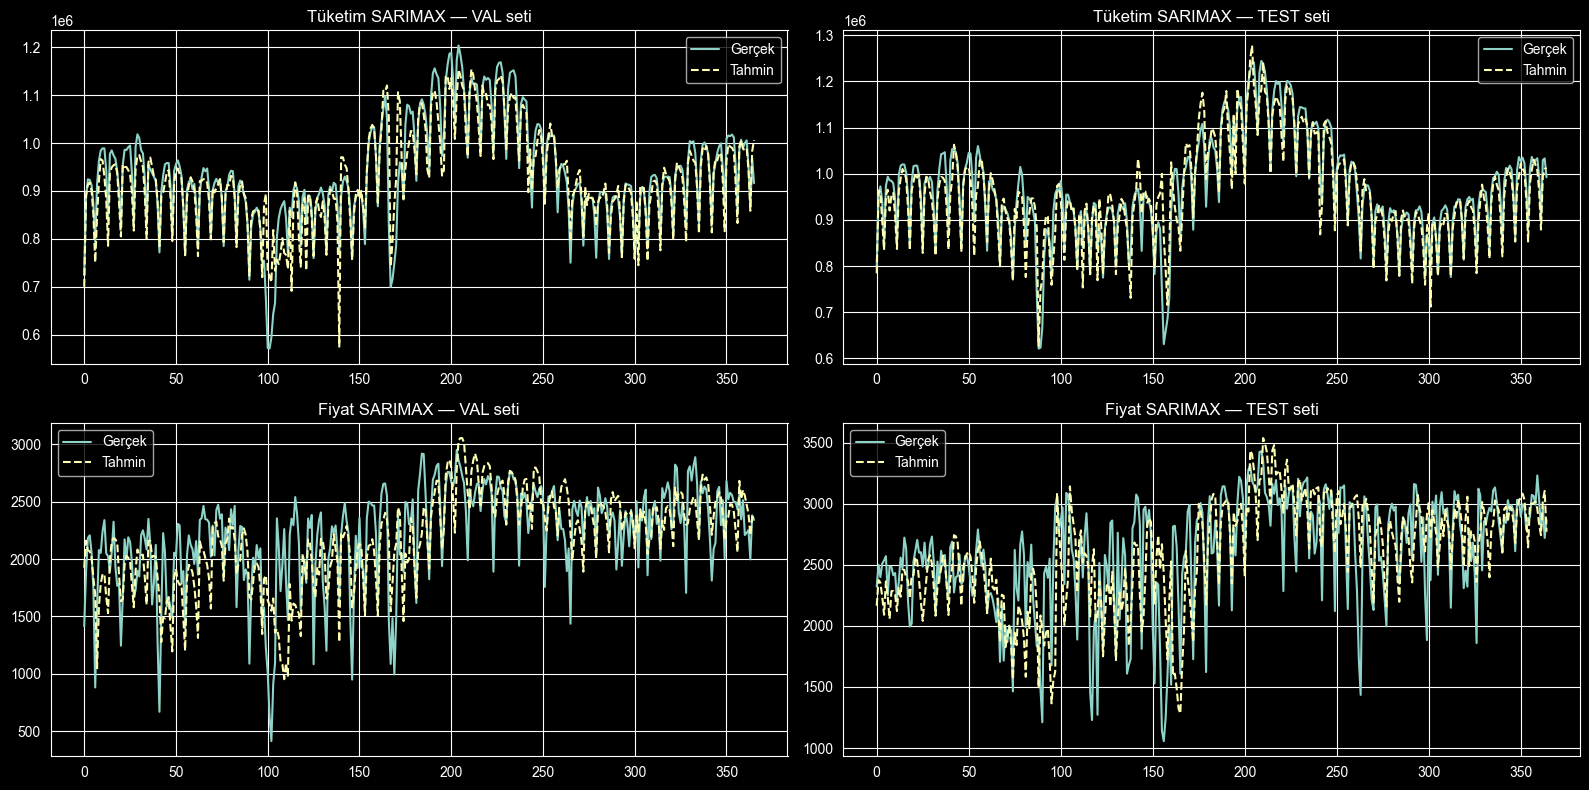

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

axes[0, 0].plot(y_val_l.values,  label="Gerçek", lw=1.5)
axes[0, 0].plot(pred_load_val.values, label="Tahmin", lw=1.5, ls="--")
axes[0, 0].set_title("Tüketim SARIMAX — VAL seti")
axes[0, 0].legend()

axes[0, 1].plot(y_test_l.values, label="Gerçek", lw=1.5)
axes[0, 1].plot(pred_load_test.values, label="Tahmin", lw=1.5, ls="--")
axes[0, 1].set_title("Tüketim SARIMAX — TEST seti")
axes[0, 1].legend()

axes[1, 0].plot(y_val_p.values,  label="Gerçek", lw=1.5)
axes[1, 0].plot(pred_price_val.values, label="Tahmin", lw=1.5, ls="--")
axes[1, 0].set_title("Fiyat SARIMAX — VAL seti")
axes[1, 0].legend()

axes[1, 1].plot(y_test_p.values, label="Gerçek", lw=1.5)
axes[1, 1].plot(pred_price_test.values, label="Tahmin", lw=1.5, ls="--")
axes[1, 1].set_title("Fiyat SARIMAX — TEST seti")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("sarimax_tahminler.png", dpi=120, bbox_inches="tight")
plt.show()

**VARMAX**

In [13]:
# 1. Fourier ve diğer özellikleri içeren fonksiyonu tanımla
def build_varmax_exog(df_daily: pd.DataFrame) -> pd.DataFrame:
    needed = [
        "sicaklik_lag1", "hissedilen_lag1", "nem_lag1",
        "ruzgar_lag1", "yagis_lag1", "bulut_lag1",
        "is_weekend", "is_holiday",
        "load_lag_7", "uretim_lag_7", "price_lag_7",
    ]
    fourier = ["sin_7", "cos_7", "sin_365", "cos_365", "sin_365_2", "cos_365_2"]

    cols = [c for c in needed + fourier if c in df_daily.columns]
    return df_daily[cols]


# 2. Endog ve Exog değişkenlerini oluştur
endog = df_daily[["tuketim_mwh", "fiyat_tl"]]
exog_var = build_varmax_exog(df_daily).dropna()

# İndeksleri eşitle (dropna sonrası kayıpları engellemek için)
endog = endog.loc[exog_var.index]

# 3. Train / Val / Test maskelerini uygulayarak veriyi böl
endog_train = endog[train_mask & endog.index.isin(exog_var.index)]
endog_val = endog[val_mask & endog.index.isin(exog_var.index)]
endog_test = endog[test_mask & endog.index.isin(exog_var.index)]

exog_train = exog_var[train_mask & exog_var.index.isin(endog.index)]
exog_val = exog_var[val_mask & exog_var.index.isin(endog.index)]
exog_test = exog_var[test_mask & exog_var.index.isin(endog.index)]

# 4. Standardizasyon (VARMAX hassastır, exog değişkenleri mutlaka ölçeklendirilmelidir)
scaler_var = StandardScaler()
X_train_var = scaler_var.fit_transform(exog_train)
X_val_var = scaler_var.transform(exog_val)
X_test_var = scaler_var.transform(exog_test)

print(f"\nVARMAX bölme:")
print(f"  Train: {endog_train.index[0].date()} → {endog_train.index[-1].date()} ({len(endog_train)} gün)")
print(f"  Val  : {endog_val.index[0].date()} → {endog_val.index[-1].date()} ({len(endog_val)} gün)")
print(f"  Test : {endog_test.index[0].date()} → {endog_test.index[-1].date()} ({len(endog_test)} gün)")


VARMAX bölme:
  Train: 2021-01-08 → 2023-12-31 (1088 gün)
  Val  : 2024-01-01 → 2024-12-31 (366 gün)
  Test : 2025-01-01 → 2025-12-31 (365 gün)


In [14]:
varmax_model = VARMAX(
    endog_train, exog=X_train_var, order=(1, 0), trend="c",
    enforce_stationarity=False, enforce_invertibility=False,
).fit(maxiter=500, disp=False)

print(f"\nVARMAX  AIC={varmax_model.aic:.2f}  BIC={varmax_model.bic:.2f}")


VARMAX  AIC=41625.56  BIC=41840.22


In [15]:
def rolling_multistep_varmax(fitted_model, endog_seen, exog_seen,
                              endog_target, exog_target_arr, horizon):
    preds = []
    curr_y = endog_seen.copy()
    curr_X = exog_seen.copy()
    n = len(endog_target)

    for start in range(0, n, horizon):
        end   = min(start + horizon, n)
        steps = end - start
        m  = fitted_model.apply(curr_y, exog=curr_X, refit=False)
        fc = m.get_forecast(steps=steps, exog=exog_target_arr[start:end])
        preds.extend(fc.predicted_mean.values)
        curr_y = pd.concat([curr_y, endog_target.iloc[start:end]])
        curr_X = np.vstack([curr_X, exog_target_arr[start:end]])

    preds_arr = np.array(preds[:n])
    return (
        pd.Series(preds_arr[:, 0], index=endog_target.index),
        pd.Series(preds_arr[:, 1], index=endog_target.index),
    )


pred_load_varmax_val, pred_price_varmax_val = rolling_multistep_varmax(
    varmax_model, endog_train, X_train_var, endog_val, X_val_var, HORIZON)

pred_load_varmax_test, pred_price_varmax_test = rolling_multistep_varmax(
    varmax_model,
    pd.concat([endog_train, endog_val]),
    np.vstack([X_train_var, X_val_var]),
    endog_test, X_test_var, HORIZON,
)

evaluate(endog_val["tuketim_mwh"],  pred_load_varmax_val,   "Load  VARMAX — Val")
evaluate(endog_test["tuketim_mwh"], pred_load_varmax_test,  "Load  VARMAX — Test")
evaluate(endog_val["fiyat_tl"],     pred_price_varmax_val,  "Price VARMAX — Val")
evaluate(endog_test["fiyat_tl"],    pred_price_varmax_test, "Price VARMAX — Test")


Load  VARMAX — Val
  RMSE  :    72,989.27
  MAE   :    61,982.15
  MAPE  :     6.67%  (|y|>10 filtresi)
  sMAPE :     6.79%
  NRMSE : 0.1153  (11.53%)

Load  VARMAX — Test
  RMSE  :    60,858.92
  MAE   :    47,307.69
  MAPE  :     5.06%  (|y|>10 filtresi)
  sMAPE :     5.06%
  NRMSE : 0.0977  (9.77%)

Price VARMAX — Val
  RMSE  :       370.17
  MAE   :       294.13
  MAPE  :    15.63%  (|y|>10 filtresi)
  sMAPE :    14.95%
  NRMSE : 0.1458  (14.58%)

Price VARMAX — Test
  RMSE  :       415.73
  MAE   :       314.16
  MAPE  :    13.13%  (|y|>10 filtresi)
  sMAPE :    13.11%
  NRMSE : 0.1751  (17.51%)


{'RMSE': np.float64(415.7312555969631),
 'MAE': 314.1558250754145,
 'MAPE': np.float64(13.129106457492043),
 'sMAPE': np.float64(13.114508072040849),
 'NRMSE': np.float64(0.17512358801816205)}

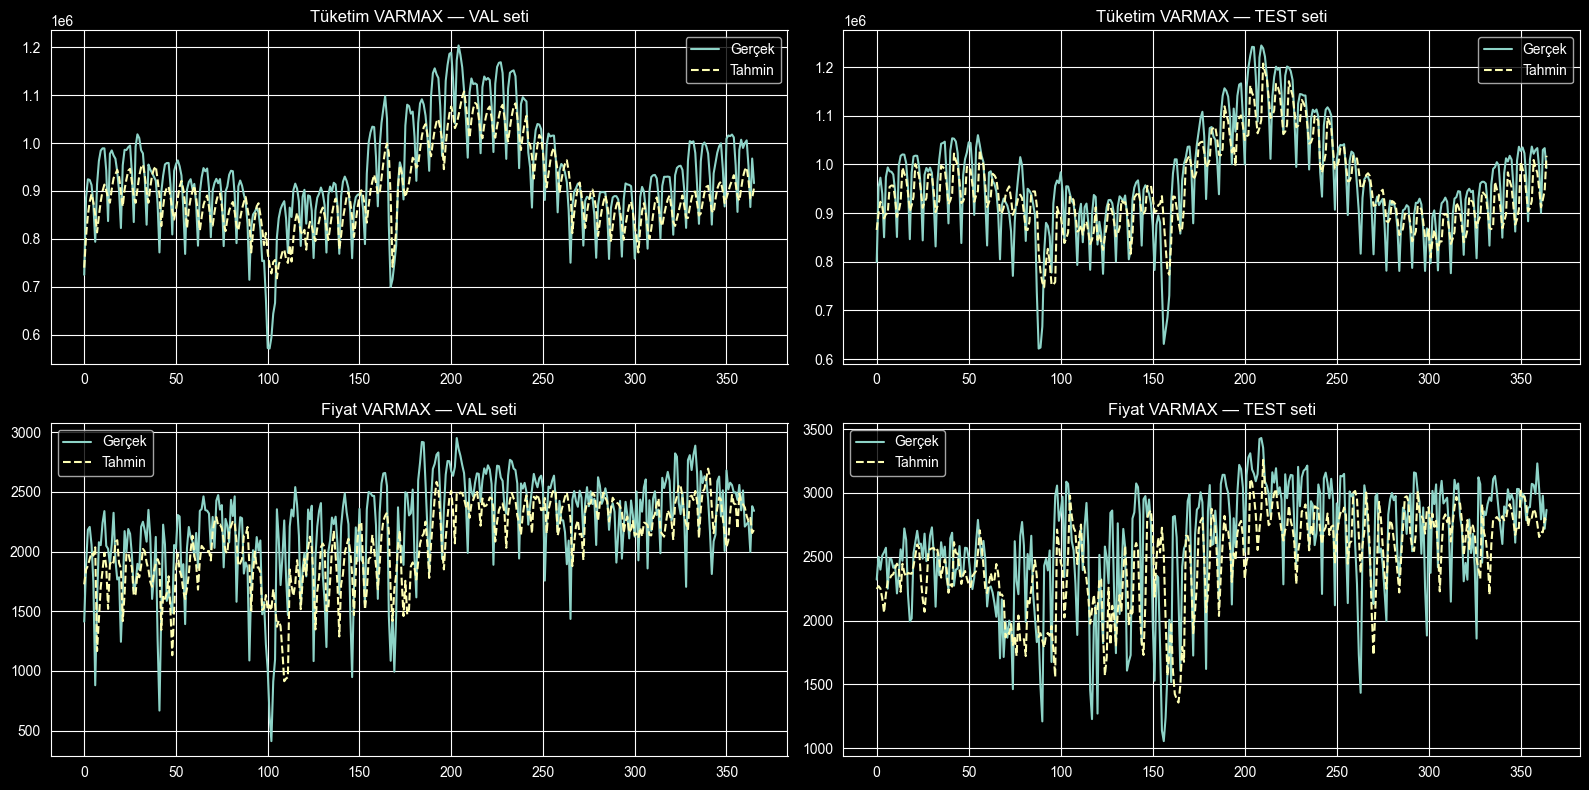

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

axes[0, 0].plot(y_val_l.values,  label="Gerçek", lw=1.5)
axes[0, 0].plot(pred_load_varmax_val.values, label="Tahmin", lw=1.5, ls="--")
axes[0, 0].set_title("Tüketim VARMAX — VAL seti")
axes[0, 0].legend()

axes[0, 1].plot(y_test_l.values, label="Gerçek", lw=1.5)
axes[0, 1].plot(pred_load_varmax_test.values, label="Tahmin", lw=1.5, ls="--")
axes[0, 1].set_title("Tüketim VARMAX — TEST seti")
axes[0, 1].legend()

axes[1, 0].plot(y_val_p.values,  label="Gerçek", lw=1.5)
axes[1, 0].plot(pred_price_varmax_val.values, label="Tahmin", lw=1.5, ls="--")
axes[1, 0].set_title("Fiyat VARMAX — VAL seti")
axes[1, 0].legend()

axes[1, 1].plot(y_test_p.values, label="Gerçek", lw=1.5)
axes[1, 1].plot(pred_price_varmax_test.values, label="Tahmin", lw=1.5, ls="--")
axes[1, 1].set_title("Fiyat VARMAX — TEST seti")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

Model Karşılaştırması

In [17]:
karsilastirma = [
    ("Load  SARIMAX",  y_test_l,                 pred_load_test,        1.0),
    ("Load  VARMAX",   endog_test["tuketim_mwh"], pred_load_varmax_test, 1.0),
    ("Price SARIMAX",  y_test_p,                 pred_price_test,       10.0),
    ("Price VARMAX",   endog_test["fiyat_tl"],   pred_price_varmax_test,10.0),
]

print(f"\n{'Model':<18} {'RMSE':>14} {'MAPE':>8} {'sMAPE':>8} {'NRMSE%':>8}")
print("-" * 62)
for label, y_true, y_pred, eps in karsilastirma:
    m = evaluate(y_true, y_pred, eps=eps)
    print(f"  {label:<16} {m['RMSE']:>12,.1f} {m['MAPE']:>7.2f}% "
          f"{m['sMAPE']:>7.2f}% {m['NRMSE']*100:>7.2f}%")


Model                        RMSE     MAPE    sMAPE   NRMSE%
--------------------------------------------------------------
  Load  SARIMAX        39,804.1    2.96%    2.94%    6.39%
  Load  VARMAX         60,858.9    5.06%    5.06%    9.77%
  Price SARIMAX           375.2   11.91%   11.43%   15.81%
  Price VARMAX            415.7   13.13%   13.11%   17.51%
